## **Classification Metrics with Tree Classifier For Cancer Detection**

More Details on the data set can be found here: [https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data](http://)

<br>
Diagnosis (M = malignant, B = benign)

# Model Training

## Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # statistical data visualization
import graphviz 
%matplotlib inline

## Data Input

In [2]:
df = pd.read_csv('/kaggle/input/breast-cancer-wisconsin-data/data.csv', index_col='id').drop('Unnamed: 32', axis=1)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Define the input and the output varaibels

In [3]:
X = df.drop(['diagnosis'], axis=1)
y = df['diagnosis']

## Map the target variable:
- M (Malignant) : 1 (positive class)
- B (Begnin) : 0 (negative class)

In [4]:
# y = y.map({'M':1, 'B':0})

## Split data into train and test set


In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

In [6]:
x_train.shape, x_test.shape

((381, 30), (188, 30))

## Decision Tree Classifier

In [7]:
# import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

In [8]:
# instantiate the DecisionTreeClassifier model with criterion gini index
model = DecisionTreeClassifier(max_depth=3)

# fit the model
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3)

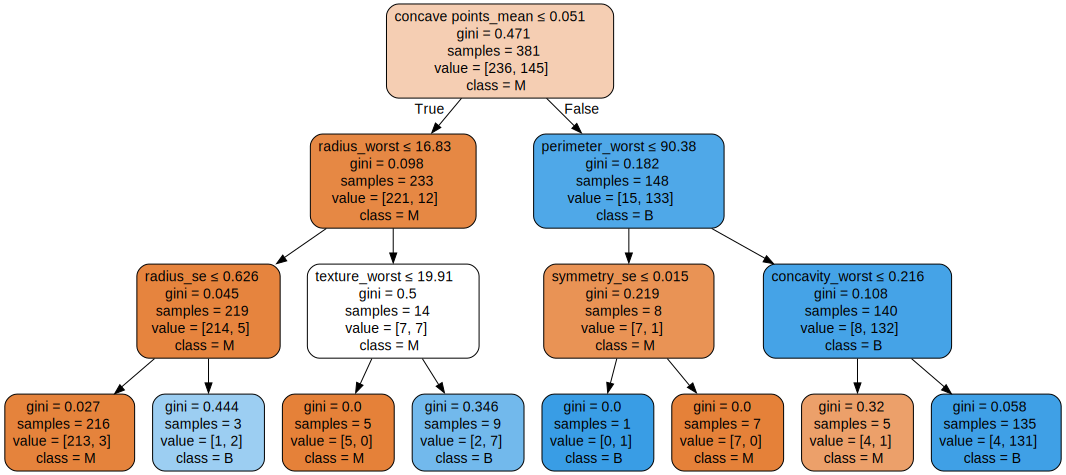

In [9]:
import graphviz 
from sklearn import tree

dot_data = tree.export_graphviz(model, out_file=None, 
                              feature_names=x_train.columns,  
                              class_names=y_train.unique(),  
                              filled=True, rounded=True,  
                              special_characters=True)

graph = graphviz.Source(dot_data)
graph 

In [10]:
213/216

0.9861111111111112

## Model Evaluation

In [11]:
print('Train Accuracy', model.score(x_train, y_train))
print('Test Accuracy', model.score(x_test, y_test))

Train Accuracy 0.9711286089238845
Test Accuracy 0.9521276595744681


## Make predictions with the model

In [12]:
y_pred = model.predict(x_test)
df_pred = pd.DataFrame().reset_index(drop=True)
df_pred['true_label'] = y_test.values
df_pred['pred_label'] = y_pred
df_pred.head(10)

,true_label,pred_label
0,B,B
1,M,M
2,M,M
3,B,B
4,B,B
5,M,M
6,M,M
7,M,M
8,B,M
9,B,B


# Metrics

Four types of outcomes are possible while evaluating a classification model performance. These four outcomes are described below:-


**True Positives (TP)** – True Positives occur when we predict an observation belongs to a certain class and the observation actually belongs to that class.


**True Negatives (TN)** – True Negatives occur when we predict an observation does not belong to a certain class and the observation actually does not belong to that class.


**False Positives (FP)** – False Positives occur when we predict an observation belongs to a    certain class but the observation actually does not belong to that class. This type of error is called **Type I error.**



**False Negatives (FN)** – False Negatives occur when we predict an observation does not belong to a certain class but the observation actually belongs to that class. This is a very serious error and it is called **Type II error.**


## **Confusion Matrix**:
   - A confusion matrix is a tabular representation of the model's predictions against actual values, providing details on true positives, true negatives, false positives, and false negatives.

In [13]:
# Print the Confusion Matrix and slice it into four pieces
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
confusion_mat = confusion_matrix(y_test, y_pred)

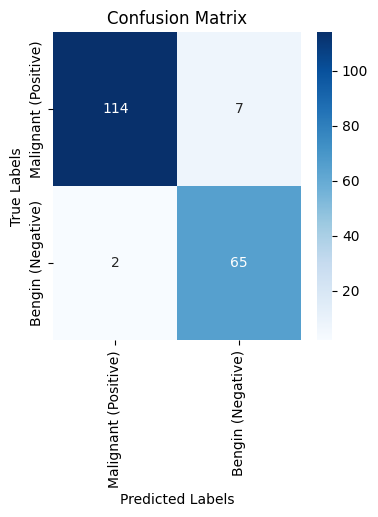

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 4))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', xticklabels=['Malignant (Positive)', 'Bengin (Negative)'], yticklabels=['Malignant (Positive)', 'Bengin (Negative)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [15]:
tn, fp, fn, tp = confusion_mat.ravel()
tn, fp, fn, tp 

(114, 7, 2, 65)

## 1. **Accuracy**:
   - Accuracy measures the ratio of correct predictions to the total number of predictions made by the model.
   - Formula: 
   
   # $ \text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}} $


In [16]:
from sklearn.metrics import accuracy_score as metric

score = metric(y_test, y_pred)

print(f'{metric.__name__}: ', score)

accuracy_score:  0.9521276595744681


In [17]:
(tp+tn)/(tp+tn+fn+fp)

0.9521276595744681

## 2. **Precision**:
   - Precision measures the ratio of true positive predictions to the total number of positive predictions made by the model.
   - Formula:
   # $ \text{Precision} = \frac{\text{True Positives}}{\text{True Positives + False Positives}}$


In [18]:
from sklearn.metrics import precision_score 

precision = precision_score(y_test, y_pred, pos_label='M')

print(f'precision_score: ', precision)

precision_score:  0.9027777777777778


In [19]:
tp / (tp+fp)

0.9027777777777778

## 3. **Recall (Sensitivity or True Positive Rate)**:
   - Recall measures the ratio of true positive predictions to the total number of actual positive instances in the dataset.
   - Formula:
   # $ \text{Recall} = \frac{\text{True Positives}}{\text{True Positives + False Negatives}}$


In [20]:
from sklearn.metrics import recall_score 

recall = recall_score(y_test, y_pred, pos_label='M')

print(f'recall_score: ', recall)

recall_score:  0.9701492537313433


In [21]:
tp / (tp+fn)

0.9701492537313433

## 4. **F1-Score**:
   - The F1-Score is the harmonic mean of precision and recall. It provides a balance between precision and recall and is particularly useful when there is an uneven class distribution.
   - Formula: 
   # $ \text{F1-Score} = \frac{2 \cdot (\text{Precision} \cdot \text{Recall})}{\text{Precision + Recall}} $


In [22]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred, pos_label='M')

print(f'{metric.__name__}: ', f1)

accuracy_score:  0.9352517985611511


In [23]:
(2 * recall * precision) / (precision + recall)

0.9352517985611511

# Classification Threshold in Decision Tree

In [24]:
# instantiate the DecisionTreeClassifier model with criterion gini index
model = DecisionTreeClassifier(max_depth=2)

# fit the model
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=2)

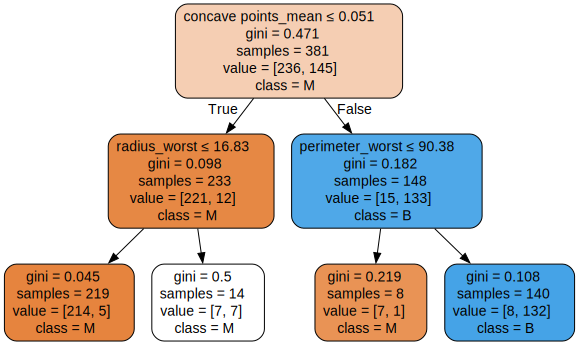

In [25]:
import graphviz 
from sklearn import tree

dot_data = tree.export_graphviz(model, out_file=None, 
                              feature_names=x_train.columns,  
                              class_names=y_train.unique(),  
                              filled=True, rounded=True,  
                              special_characters=True)

graph = graphviz.Source(dot_data)
graph 

In [26]:
221/233

0.9484978540772532

<img src='https://developers.google.com/static/machine-learning/crash-course/images/PrecisionVsRecallRaiseThreshold.svg'>
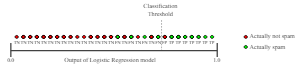
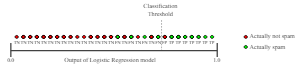

In [27]:
pred_prob = model.predict_proba(x_test)

threshold = 0.5

pred_crisp = (pred_prob[:, 1] > threshold).astype(int)

predictions = pd.DataFrame(pred_prob, columns=['probability of B', 'probability of M'])
predictions['true_lable'] = y_test.values
predictions['pred_label'] = pred_crisp
predictions['pred_label'] = predictions['pred_label'].map({0:'B', 1:'M'})

In [28]:
predictions

,probability of B,probability of M,true_lable,pred_label
0,0.977169,0.022831,B,B
1,0.057143,0.942857,M,M
2,0.057143,0.942857,M,M
3,0.977169,0.022831,B,B
4,0.977169,0.022831,B,B
...,...,...,...,...
183,0.057143,0.942857,M,M
184,0.057143,0.942857,M,M
185,0.057143,0.942857,M,M
186,0.977169,0.022831,B,B
